In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from scipy.stats import linregress
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


# select demand for victoria and sort in order of date
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/VIC_clean.csv")
demand.sort()

df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")



CSV files loaded


C:\Users\Coder\AppData\Local\Temp\ipykernel_25268\264807496.py:20: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\Coder\AppData\Local\Temp\ipykernel_25268\264807496.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside


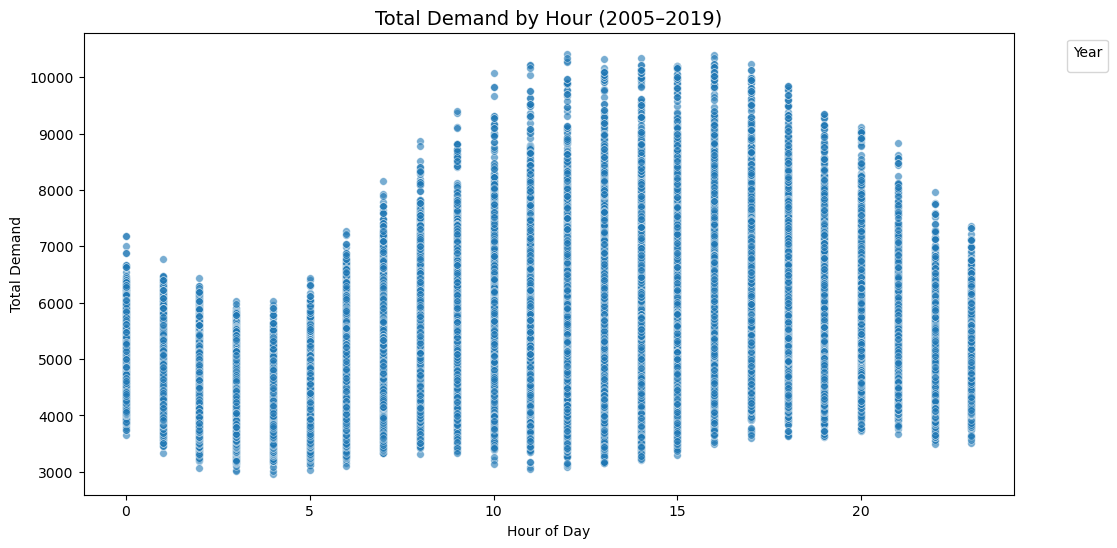

In [3]:
df = pd.concat(df_list, ignore_index=True)

# Parse datetime column
df['Datetime'] = df['Datetime'].str.replace(r'\+.*$', '', regex=True)  # Remove timezone
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y-%m-%d %H:%M:%S")

# Extract hour of the day
df['Hour'] = df['Datetime'].dt.hour

# Extract year column
df['Year'] = df['Datetime'].dt.year

df['Day'] = df['Datetime'].dt.day_name()




# Scatter plot with color by year
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x="Hour",
    y="Total Demand",
    palette="tab20",       # 20 distinct colors (good for many years)
    legend="full",
    s=30,                  # marker size
    alpha=0.6              # transparency
)

plt.title("Total Demand by Hour (2005–2019)", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Total Demand")
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside
plt.show()

In [26]:
# Data Seperation as X and Y

x = df[['Datetime']].copy()
x['month'] = x['Datetime'].dt.month
x = x[['month']]  # keep only month as feature

y = df['Total Demand']

#Data splitting

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=100)


#print(len(X_train)) # 80% of data size

#print(len(X_test)) # 20% of data size

#print(len(x)) # Original Data size


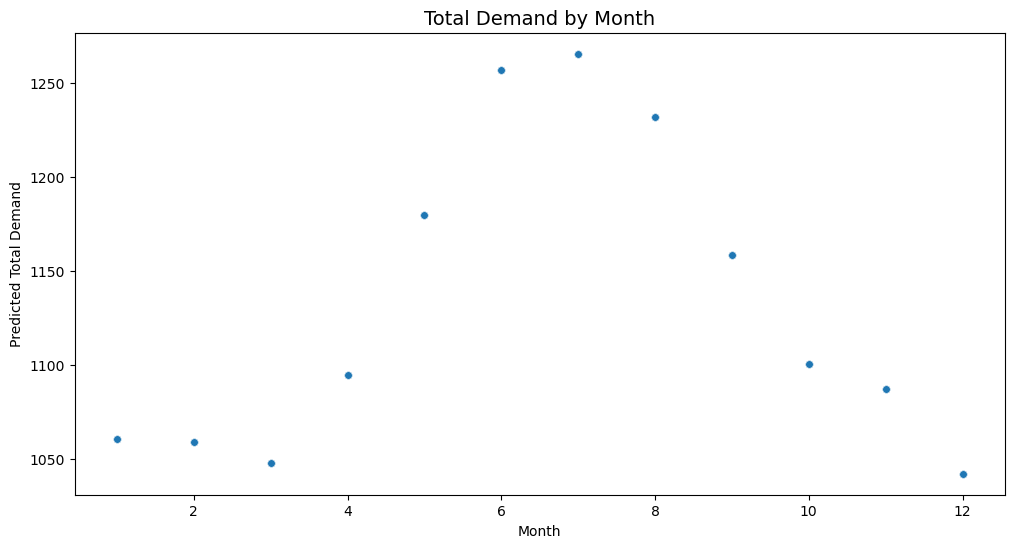

          Method  Training MSE Training R2      Test MSE   Test R2
0  Random forest  17071.037134    0.273272  17150.892224  0.270536


In [49]:
# Model Building with Random forest

# Training the model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, Y_train)

# Applying the model to make a prediction

y_rf_train_pred = rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)

# Model performance
from sklearn.metrics import mean_squared_error, r2_score

rf_train_mse = mean_squared_error(Y_train, y_rf_train_pred)
rf_train_r2 = r2_score(Y_train, y_rf_train_pred)

rf_test_mse = mean_squared_error(Y_test, y_rf_test_pred)
rf_test_r2 = r2_score(Y_test, y_rf_test_pred)

plot_df = pd.DataFrame({
    "Month": X_test.values.flatten(),
    "Predicted_Demand": y_rf_test_pred
})

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=plot_df,
    x="Month",
    y="Predicted_Demand",
    s=30,
    alpha=0.6
)

plt.title("Total Demand by Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Predicted Total Demand")
plt.show()

rf_results = pd.DataFrame(["Random forest", rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results.columns = ["Method", "Training MSE", "Training R2", "Test MSE", "Test R2"]
print(rf_results)


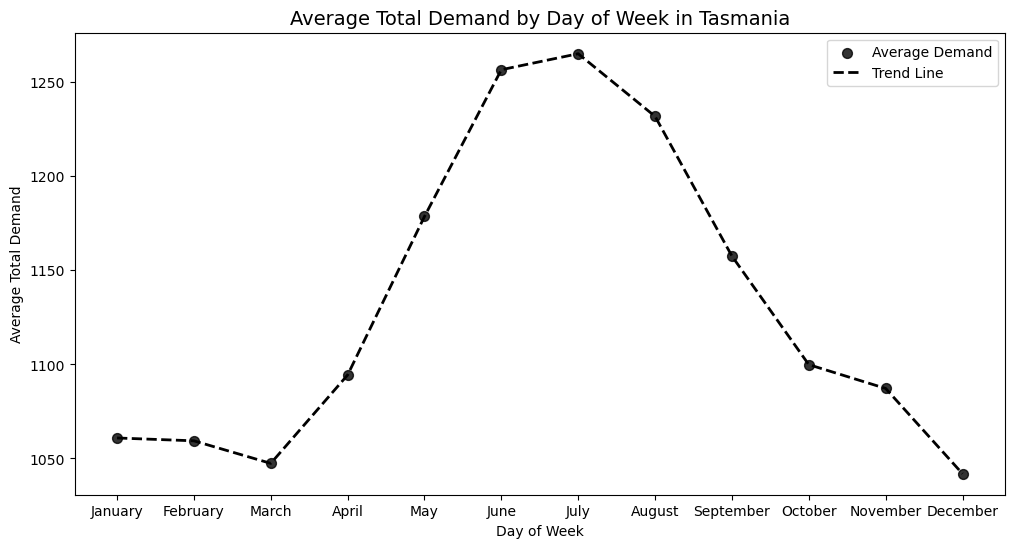

Average Total Demand by Month
Month
January      1060.88
February     1059.37
March        1047.37
April        1094.39
May          1178.65
June         1256.68
July         1265.19
August       1231.88
September    1157.60
October      1099.88
November     1087.22
December     1041.88
Name: Total Demand, dtype: float64


In [46]:
import matplotlib.pyplot as plt
import pandas as pd


df['Month'] = df['Datetime'].dt.month_name()
# Define the correct order of days
day_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
#day_order = ['September', 'October', 'November', 'December', 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', ]

# Calculate average total demand for each day
average_demand_by_month = df.groupby('Month')['Total Demand'].mean()

# Reindex to ensure days are ordered from Monday to Sunday
average_demand_by_month = average_demand_by_month.reindex(day_order)

# Create scatter plot with a connecting line
plt.figure(figsize=(12, 6))
plt.scatter(average_demand_by_month.index, average_demand_by_month.values, 
            color='black', s=50, alpha=0.8, label='Average Demand')
plt.plot(average_demand_by_month.index, average_demand_by_month.values, 
         color='black', linewidth=2, linestyle='--', label='Trend Line')

# Update title and labels
plt.title("Average Total Demand by Day of Week in Tasmania", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Average Total Demand")
plt.legend()

# Show plot
plt.show()

# Print the averages
print("Average Total Demand by Month")
print(average_demand_by_month.round(2))


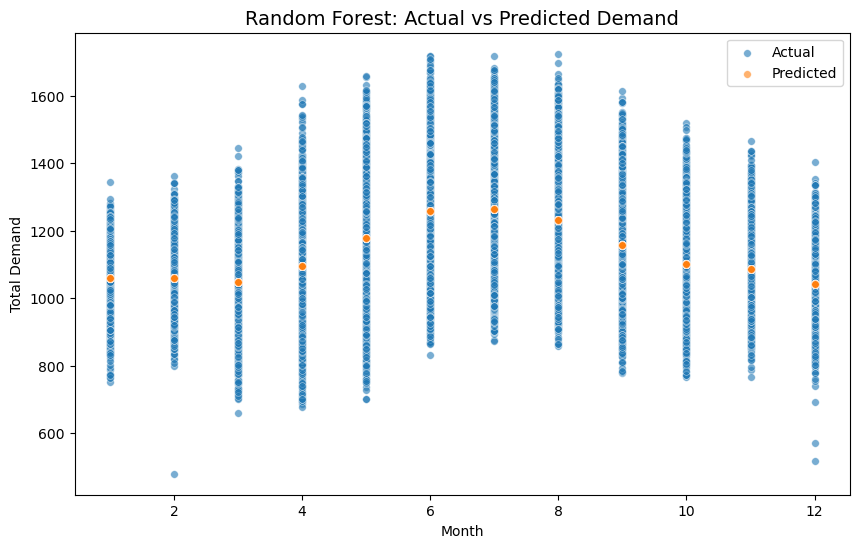

In [51]:
# Model Comparison

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Build a DataFrame with actual vs predicted
plot_df = pd.DataFrame({
    "Month": X_test.values.flatten(),
    "Actual_Demand": Y_test.values.flatten(),
    "Predicted_Demand": y_rf_test_pred
})

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="Month",
    y="Actual_Demand",
    s=30, alpha=0.6, label="Actual"
)
sns.scatterplot(
    data=plot_df,
    x="Month",
    y="Predicted_Demand",
    s=30, alpha=0.6, label="Predicted"
)

plt.title("Random Forest: Actual vs Predicted Demand", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Demand")
plt.legend()
plt.show()


C:\Users\Coder\AppData\Local\Temp\ipykernel_17688\4043686329.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\Coder\AppData\Local\Temp\ipykernel_17688\4043686329.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside


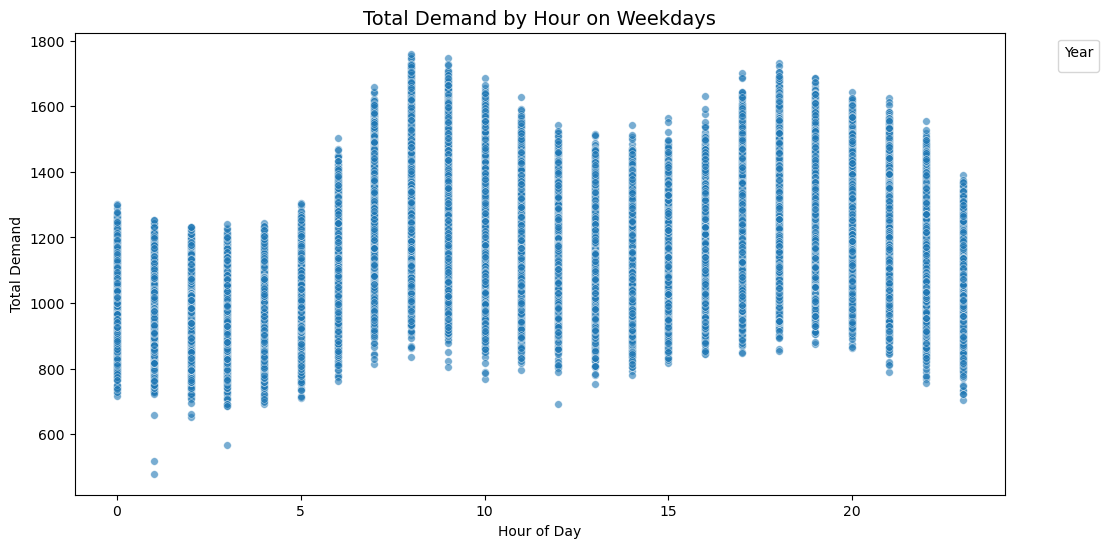

In [11]:
# Filter for weekends (Saturday and Sunday)
df_weekends = df[df['Day'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thuresday', 'Friday'])]

# Scatter plot with color by year for weekends only
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_weekends,
    x="Hour",
    y="Total Demand",
    palette="tab20",       # 20 distinct colors (good for many years)
    legend="full",
    s=30,                  # marker size
    alpha=0.6              # transparency
)

plt.title("Total Demand by Hour on Weekdays", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Total Demand")
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside
plt.show()

C:\Users\Coder\AppData\Local\Temp\ipykernel_17688\886337118.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\Coder\AppData\Local\Temp\ipykernel_17688\886337118.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside


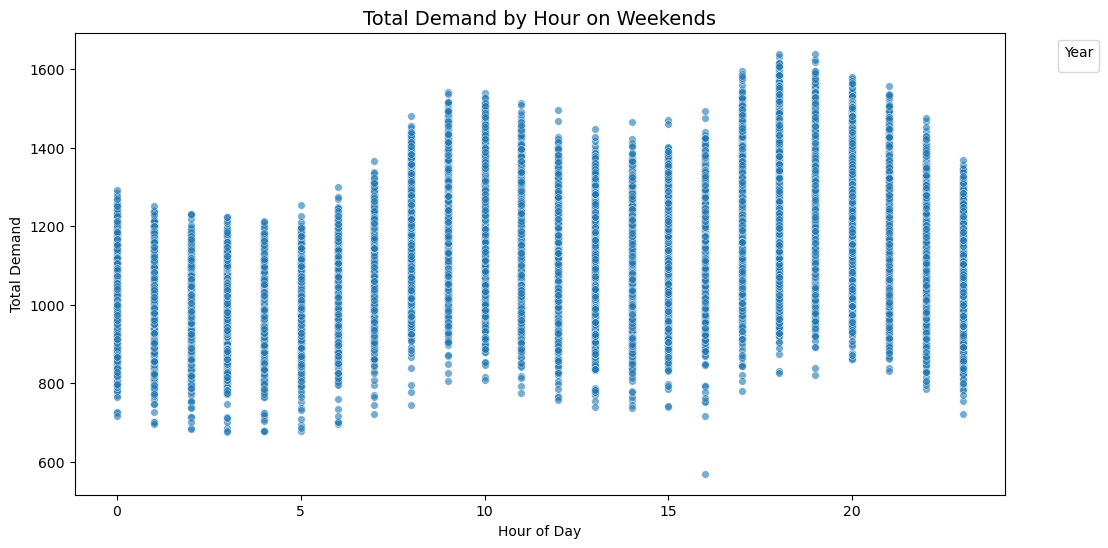

In [12]:
# Filter for weekends (Saturday and Sunday)
df_weekends = df[df['Day'].isin(['Saturday', 'Sunday'])]

# Scatter plot with color by year for weekends only
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_weekends,
    x="Hour",
    y="Total Demand",
    palette="tab20",       # 20 distinct colors (good for many years)
    legend="full",
    s=30,                  # marker size
    alpha=0.6              # transparency
)

plt.title("Total Demand by Hour on Weekends", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Total Demand")
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside
plt.show()

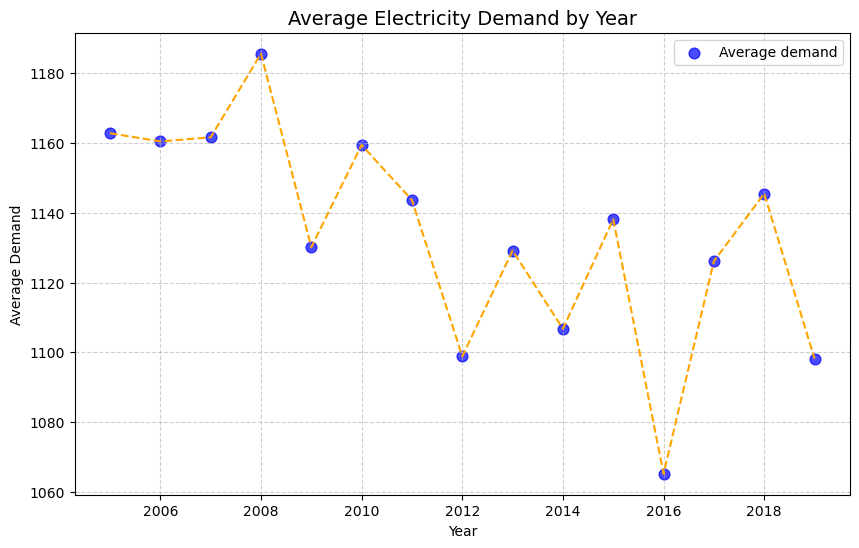

In [28]:
# Extract year column
df['Year'] = df['Datetime'].dt.year

# Compute average demand per year
avg_demand_year = df.groupby('Year')['Total Demand'].mean().reset_index()

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(
    avg_demand_year['Year'], 
    avg_demand_year['Total Demand'], 
    color='blue', 
    s=60, 
    alpha=0.7,
    label="Average demand"
)

plt.plot(avg_demand_year['Year'], avg_demand_year['Total Demand'], color='orange', linestyle='--')  # optional trend line

plt.title("Average Electricity Demand by Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average Demand")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

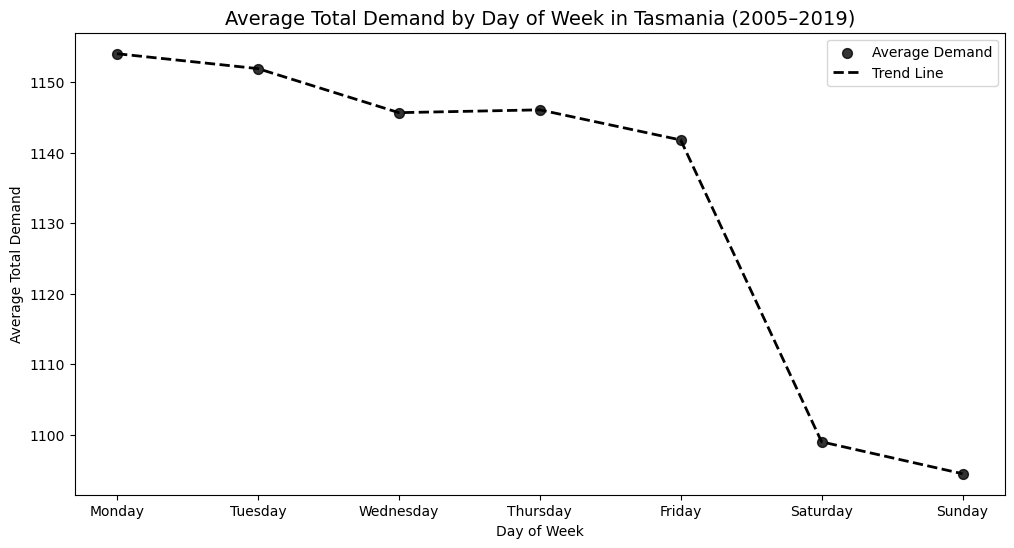

Average Total Demand by Day of Week:
Day
Monday       1154.05
Tuesday      1151.94
Wednesday    1145.69
Thursday     1146.09
Friday       1141.81
Saturday     1098.97
Sunday       1094.45
Name: Total Demand, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


df['Day'] = df['Datetime'].dt.day_name()
# Define the correct order of days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Calculate average total demand for each day
average_demand_by_day = df.groupby('Day')['Total Demand'].mean()

# Reindex to ensure days are ordered from Monday to Sunday
average_demand_by_day = average_demand_by_day.reindex(day_order)

# Create scatter plot with a connecting line
plt.figure(figsize=(12, 6))
plt.scatter(average_demand_by_day.index, average_demand_by_day.values, 
            color='black', s=50, alpha=0.8, label='Average Demand')
plt.plot(average_demand_by_day.index, average_demand_by_day.values, 
         color='black', linewidth=2, linestyle='--', label='Trend Line')

# Update title and labels
plt.title("Average Total Demand by Day of Week in Tasmania", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Average Total Demand")
plt.legend()

# Show plot
plt.show()

# Print the averages
print("Average Total Demand by Day of Week:")
print(average_demand_by_day.round(2))



Energy by Month

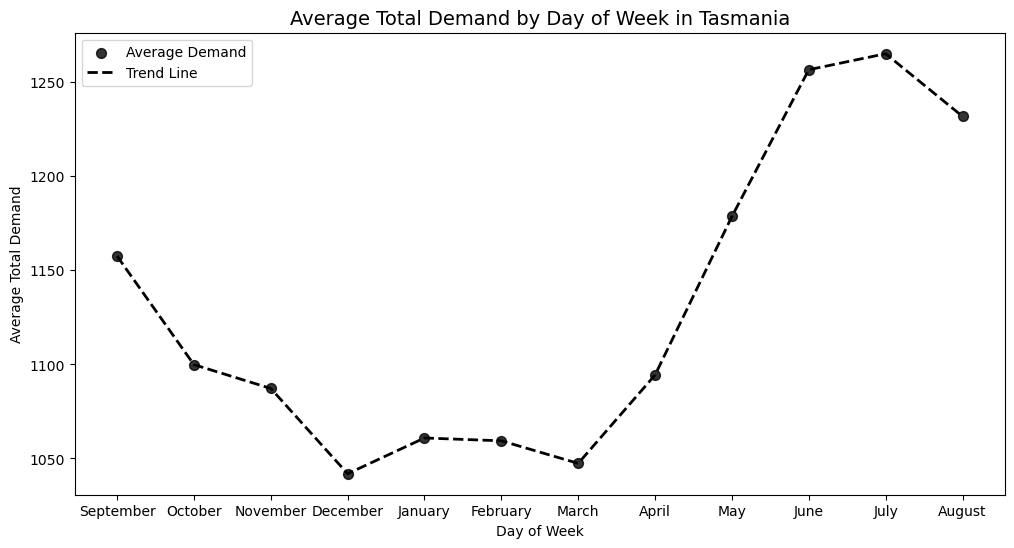

Average Total Demand by Month
Month
September    1157.60
October      1099.88
November     1087.22
December     1041.88
January      1060.88
February     1059.37
March        1047.37
April        1094.39
May          1178.65
June         1256.68
July         1265.19
August       1231.88
Name: Total Demand, dtype: float64


In [6]:
import matplotlib.pyplot as plt
import pandas as pd


df['Month'] = df['Datetime'].dt.month_name()
# Define the correct order of days
#day_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
day_order = ['September', 'October', 'November', 'December', 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', ]

# Calculate average total demand for each day
average_demand_by_month = df.groupby('Month')['Total Demand'].mean()

# Reindex to ensure days are ordered from Monday to Sunday
average_demand_by_month = average_demand_by_month.reindex(day_order)

# Create scatter plot with a connecting line
plt.figure(figsize=(12, 6))
plt.scatter(average_demand_by_month.index, average_demand_by_month.values, 
            color='black', s=50, alpha=0.8, label='Average Demand')
plt.plot(average_demand_by_month.index, average_demand_by_month.values, 
         color='black', linewidth=2, linestyle='--', label='Trend Line')

# Update title and labels
plt.title("Average Total Demand by Day of Week in Tasmania", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Average Total Demand")
plt.legend()

# Show plot
plt.show()

# Print the averages
print("Average Total Demand by Month")
print(average_demand_by_month.round(2))


<function matplotlib.pyplot.show(close=None, block=None)>

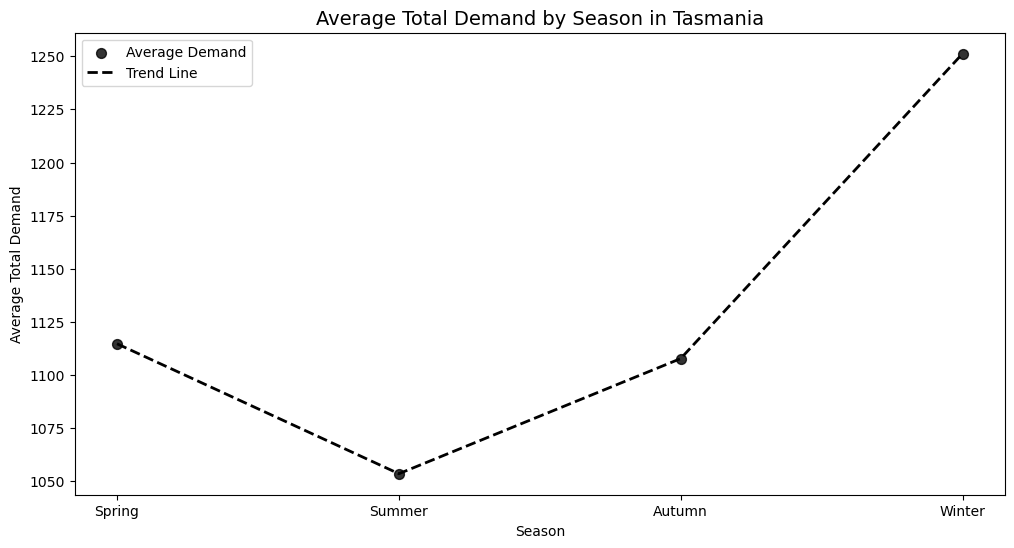

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df is already defined with 'Datetime' and 'Total Demand' columns
df['Month'] = df['Datetime'].dt.month_name()

# Define seasons based on months in Tasmania
season_mapping = {
    'September': 'Spring', 'October': 'Spring', 'November': 'Spring',
    'December': 'Summer', 'January': 'Summer', 'February': 'Summer',
    'March': 'Autumn', 'April': 'Autumn', 'May': 'Autumn',
    'June': 'Winter', 'July': 'Winter', 'August': 'Winter'
}

# Add a 'Season' column to the dataframe
df['Season'] = df['Month'].map(season_mapping)

# Define the correct order of seasons
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']

# Calculate average total demand for each season
average_demand_by_season = df.groupby('Season')['Total Demand'].mean()

# Reindex to ensure seasons are ordered correctly
average_demand_by_season = average_demand_by_season.reindex(season_order)

# Create scatter plot with a connecting line
plt.figure(figsize=(12, 6))
plt.scatter(average_demand_by_season.index, average_demand_by_season.values, 
            color='black', s=50, alpha=0.8, label='Average Demand')
plt.plot(average_demand_by_season.index, average_demand_by_season.values, 
         color='black', linewidth=2, linestyle='--', label='Trend Line')

# Update title and labels
plt.title("Average Total Demand by Season in Tasmania", fontsize=14)
plt.xlabel("Season")
plt.ylabel("Average Total Demand")
plt.legend()

# Show plot
plt.show